In [3]:
import pandas as pd
import numpy as np
import scipy as sp
import sklearn
import importlib




In [2]:
import databox as db
import joblib
# import sample_group_stats as sgst


In [5]:
ce_df = pd.read_parquet("data/q_sep/context_encoding_df.pq")

In [6]:
wg_df = pd.read_parquet("data/q_sep/wordgram_df.pq")

In [149]:
wg_tr = sklearn.decomposition.FastICA(n_components=8, random_state=42)
ce_tr = sklearn.decomposition.FastICA(n_components=8, random_state=42)

wg_tr.fit(wg_df.groupby('category').head(2000))
ce_tr.fit(ce_df.groupby('category').head(2000))



['data/q_sep/CE-ICA_transformer_w_8-dim.pkl']

In [150]:
#joblib.dump(wg_tr,'data/q_sep/WG-ICA_transformer_w_8-dim.pkl')
#joblib.dump(ce_tr,'data/q_sep/CE-ICA_transformer_w_8-dim.pkl')

wg_tr = joblib.load('data/q_sep/WG-ICA_transformer_w_8-dim.pkl')
ce_tr = joblib.load('data/q_sep/CE-ICA_transformer_w_8-dim.pkl')



In [346]:
wg_i = pd.DataFrame(wg_tr.transform(wg_df),index=wg_df.index)
wg_i.sample(5)

,,0,1,2,3,4,5,6,7
token_id,category,,,,,,,,
Sca-7ebf_141_bat-14,topic,0.376765,-0.098469,0.719286,0.437191,-0.244443,0.043963,0.303409,-0.119716
Bee-f189_104_beech-4,topic,-1.918080,0.851014,-0.257200,-0.217070,0.181806,0.209169,-0.741172,1.044502
Sil-6383_103_sifaka-3,topic,0.034499,-0.563208,0.250646,0.302452,-0.550971,-0.373802,0.053610,-0.207211
Bla-30a4_131_blackberry-7,topic,-0.673545,0.727902,0.769181,-0.326717,-1.097514,-0.196473,-0.482024,0.589167
Neo-e4e0_11_toads-38,topic,0.045483,-0.799408,0.212518,0.597783,-0.494033,-0.198632,-0.266678,-0.234817


In [152]:
ce_i = pd.DataFrame(ce_tr.transform(ce_df),index=ce_df.index)
ce_i.sample(5)

,,0,1,2,3,4,5,6,7
token_id,category,,,,,,,,
Clo-8e0e_110_vertebrates-9,topic,1.313830,-1.139519,-0.363289,0.483379,1.105449,0.639770,0.105806,-0.219802
Arc-cf8f_182_animals-24,topic,-2.062381,-0.462345,0.095053,1.866206,0.654182,1.419668,-0.035573,-1.096289
Dun9430_14_beetles-19,taxongroup,-0.733625,0.609887,-0.221538,-0.080454,-0.013892,0.648095,-0.013495,-0.354828
Eur-3ec7_359_owl-5,topic,-0.440999,-1.219579,0.621111,-0.454077,-1.364810,0.274048,0.413986,-0.654248
Syn-2ca8_22_seahorses-9,topic,1.137893,-1.545220,-0.127493,-0.634631,0.186522,0.136678,-0.530669,0.131228


In [347]:
#wg_i.to_parquet("data/q_sep/WG-ICA_data_8-dim.pq")
#ce_i.to_parquet("data/q_sep/CE-ICA_data_8-dim.pq")



In [356]:
from sklearn.mixture import BayesianGaussianMixture

bgms = {}


wgdf = wg_i.reset_index().set_index(['category','token_id']).sort_index()
cedf = ce_i.reset_index().set_index(['category','token_id']).sort_index()
categories = cedf.index.droplevel(1).unique()
categories




In [380]:
wgdf = wg_i.reset_index().set_index(['category','token_id']).sort_index()
cedf = ce_i.reset_index().set_index(['category','token_id']).sort_index()


In [381]:
for model_id in ['ce','wg']:
    for cat_id in categories:
        bgm_id = '%s_%s' % (model_id, cat_id)
        bgms[bgm_id]=None
        df = wgdf if model_id=='wg' else cedf
        
        print ("Fitting %s dataset... (%s)"%(bgm_id,str(df.loc[cat_id].shape)))
        bgm = BayesianGaussianMixture(n_components=8,tol=0.001,max_iter=1000,random_state=42,covariance_type='full')
        bgm.fit(df.loc[cat_id].iloc[0:1000])
        bgms[bgm_id]=bgm
        print("BGM stored")
        

Fitting ce_adaptation dataset... ((3578, 6))
BGM stored
Fitting ce_location dataset... ((2539, 6))
BGM stored
Fitting ce_taxongroup dataset... ((8361, 6))
BGM stored
Fitting ce_topic dataset... ((39533, 6))
BGM stored
Fitting wg_adaptation dataset... ((3578, 6))
BGM stored
Fitting wg_location dataset... ((2539, 6))
BGM stored
Fitting wg_taxongroup dataset... ((8361, 6))
BGM stored
Fitting wg_topic dataset... ((39533, 6))
BGM stored


In [382]:
#joblib.dump(bgms,"data/q_sep/BGMs-ce-wg-8d.pkl")

In [383]:
grid_data = []

for x in categories:
    for y in categories:
        for m in ['ce','wg']:
            ica_df = (cedf if m=='ce' else wgdf)
            s = bgms[m+'_'+x].score(ica_df.loc[y].iloc[1000:2000])
            grid_data.append((m,x,y,s))

    
grid_df = pd.DataFrame(grid_data,columns=['projection','BGM_model','test_set','loglhood'])
grid_df = grid_df.set_index(['projection','BGM_model','test_set']).sort_index()

In [384]:

ce_grid = grid_df.loc['ce'].reset_index()
pd.crosstab(ce_grid.BGM_model,ce_grid.test_set,ce_grid.loglhood,aggfunc=sum).round(2)



test_set,adaptation,location,taxongroup,topic
BGM_model,,,,
adaptation,-7.93,-7.62,-9.15,-7.64
location,-8.96,-7.32,-9.32,-7.66
taxongroup,-8.23,-7.59,-8.58,-7.43
topic,-8.52,-7.47,-8.93,-7.22


In [385]:
wg_grid = grid_df.loc['wg'].reset_index()
pd.crosstab(wg_grid.BGM_model,
            wg_grid.test_set,
            wg_grid.loglhood,
            aggfunc=sum).round(2)


test_set,adaptation,location,taxongroup,topic
BGM_model,,,,
adaptation,-5.64,-9.53,-9.16,-6.22
location,-7.02,-6.98,-9.78,-6.66
taxongroup,-6.42,-10.57,-8.14,-5.59
topic,-6.38,-8.50,-7.87,-5.59


In [326]:
b = bgms['ce_adaptation']


In [327]:
b.score(bgms['ce_adaptation'].sample(1000)[0]).round(3)

-9.123

In [333]:
bins = pd.Series(b.predict(cedf.loc['adaptation'].iloc[0:3000])).value_counts().sort_index()
bins

0    794
1    970
2    894
3    342
Name: count, dtype: int64

In [305]:
df = cedf # context encodings
#df = wgdf # wordgram data

pgd = df[df.columns[0:3]].reset_index().set_index('token_id')

pgd=pgd.groupby('category').sample(50)
pgd

# Uncomment for simulated data
#
#samples = bgms['ce_topic'].sample(500)
#df = pd.DataFrame(samples[0])
#pgd = df[df.columns[0:3]].copy()#.reset_index().set_index('token_id')
#pgd['category']=samples[1]


,category,0,1,2
token_id,,,,
Tyr-70f1_341_scavenger-5,adaptation,0.094094,0.661946,-0.550122
Add-f0f0_101_hibernation-14,adaptation,-0.109765,0.026780,-1.205754
Pte-62aa_599_predators-8,adaptation,-0.442253,0.989527,0.388892
Kud-baf3_43_Predators-1,adaptation,-3.295255,-1.539962,-2.363953
Bir-959d_29_scavengers-3,adaptation,-1.182404,0.322706,1.546533
...,...,...,...,...
Bee-1811_53_conifers-20,topic,-0.289990,-1.833359,-0.252946
Man-5294_3_mantid-20,topic,-0.616876,0.375795,1.153207
Hor-ab9c_79_bats-3,topic,0.564493,0.692393,-0.650193


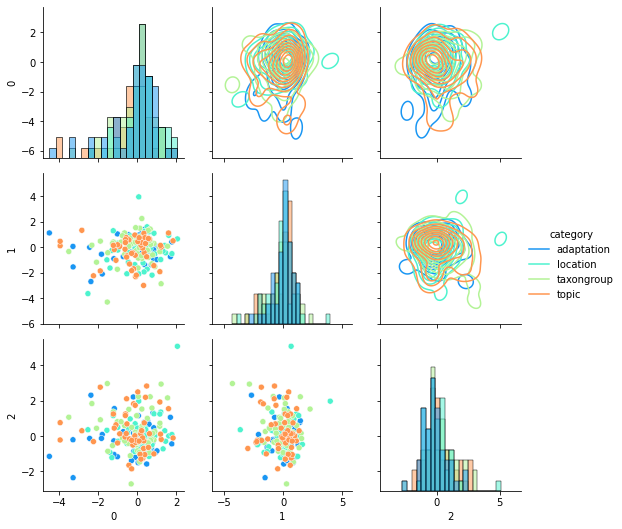

In [306]:
import seaborn as sns
     
g = sns.PairGrid(pgd,hue='category',palette='rainbow')
g.map_lower(sns.scatterplot)
g.map_upper(sns.kdeplot)
g.map_diag(sns.histplot)
g.add_legend()

In [324]:
cedf[0].dtype

dtype('float64')